In [1]:
%%capture --no-stderr
%pip install -U langchain_openai langgraph trustcall langchain_core

In [2]:
%pip install langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.1 MB/s eta 0:00:00


In [3]:
%pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 28.7 MB/s eta 0:00:00


In [4]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
import sys
sys.path.append('/content/drive/MyDrive/Baot/30_NLP_2025/Tair')

In [7]:
from langchain_core.messages import ToolCall


In [32]:
import importlib
import graph_nodes
importlib.reload(graph_nodes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<module 'graph_nodes' from '/content/drive/MyDrive/Baot/30_NLP_2025/Tair/graph_nodes.py'>

In [11]:
from graph_nodes import State, assistant, upload_image, display_image, identify_food, get_calories, get_image_path_node
from graph_nodes import tools , tools_condition

ImportError: cannot import name 'tools' from 'graph_nodes' (/content/drive/MyDrive/Baot/30_NLP_2025/Tair/graph_nodes.py)

In [45]:
import importlib
importlib.reload(graph_nodes)
from graph_nodes import State, assistant, get_image_path, upload_image, display_image, identify_food, get_calories # get_image_path_node
from graph_nodes import tools , tools_condition

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



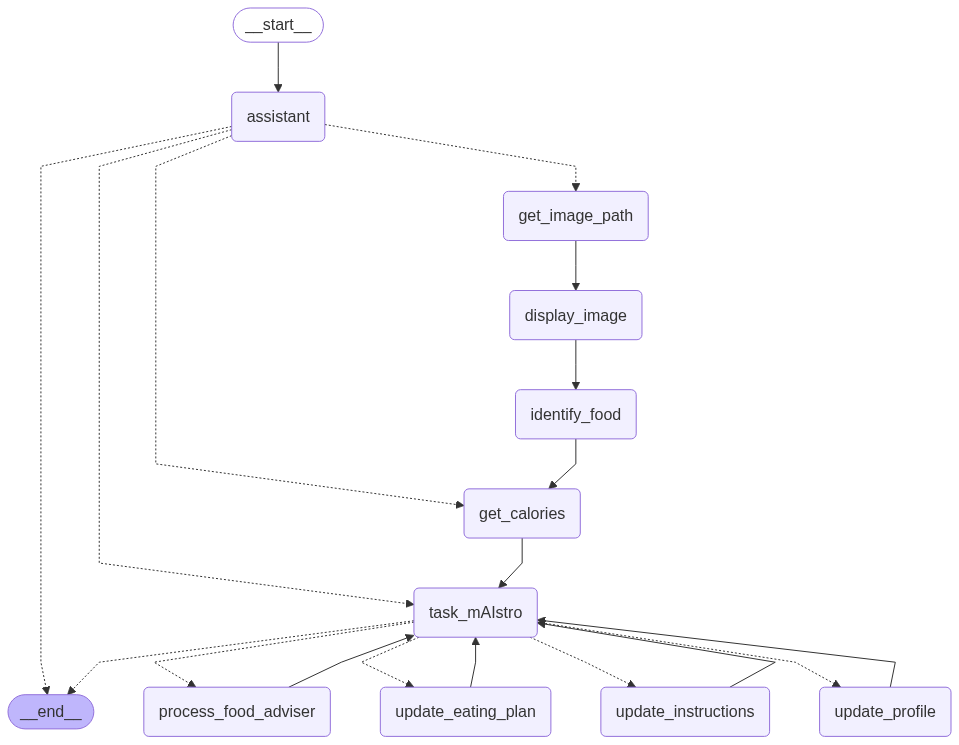

In [49]:
# Unified graph: supports text or image calorie estimation, then memory updates
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langgraph.graph import MessagesState
from langchain_core.messages import merge_message_runs,HumanMessage, SystemMessage, ToolMessage
from langgraph.prebuilt import ToolNode
from trustcall import create_extractor
from typing import TypedDict, Literal, Union
from graph_nodes import State, assistant, upload_image, display_image, identify_food, get_calories, get_image_path_node
from graph_nodes import tools , tools_condition
from rag import get_rag


# from tools import tools, food_adviser_tool
from langchain_openai import ChatOpenAI
from datetime import datetime
import uuid

llm = ChatOpenAI(model="gpt-4o")
# llm = llm.bind_tools(tools, parallel_tool_calls=False)
rag_chain = get_rag(llm)

# Update memory tool
class UpdateMemory(TypedDict):
    """ Decision on what memory type to update """
    update_type: Literal['user', 'eating_plan', 'instructions']

from pydantic import BaseModel, Field

class Memory(BaseModel):
    content: str = Field(description="The main content of the memory. For example: User expressed interest in learning about French.")

class MemoryCollection(BaseModel):
    memories: list[Memory] = Field(description="A list of memories about the user.")

# Inspect the tool calls made by Trustcall
class Spy:
    def __init__(self):
        self.called_tools = []

    def __call__(self, run):
        # Collect information about the tool calls made by the extractor.
        q = [run]
        while q:
            r = q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type == "chat_model":
                self.called_tools.append(
                    r.outputs["generations"][0][0]["message"]["kwargs"]["tool_calls"]
                )

# Initialize the spy
spy = Spy()

# Initialize the model
model = ChatOpenAI(model="gpt-4o", temperature=0)

# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[Memory],
    tool_choice="Memory",
    enable_inserts=True,
)

# Add the spy as a listener
trustcall_extractor_see_all_tool_calls = trustcall_extractor.with_listeners(on_end=spy)

def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls for both patches and new memories.

    Args:
        tool_calls: List of tool calls from the model
        schema_name: Name of the schema tool (e.g., "Memory", "ToDo", "Profile")
    """

    # Initialize list of changes
    changes = []

    for call_group in tool_calls:
        for call in call_group:
            if call['name'] == 'PatchDoc':
                changes.append({
                    'type': 'update',
                    'doc_id': call['args']['json_doc_id'],
                    'planned_edits': call['args']['planned_edits'],
                    'value': call['args']['patches'][0]['value']
                })
            elif call['name'] == schema_name:
                changes.append({
                    'type': 'new',
                    'value': call['args']
                })

    # Format results as a single string
    result_parts = []
    for change in changes:
        if change['type'] == 'update':
            result_parts.append(
                f"Document {change['doc_id']} updated:\n"
                f"Plan: {change['planned_edits']}\n"
                f"Added content: {change['value']}"
            )
        else:
            result_parts.append(
                f"New {schema_name} created:\n"
                f"Content: {change['value']}"
            )

    return "\n\n".join(result_parts)

# Inspect spy.called_tools to see exactly what happened during the extraction
schema_name = "Memory"
changes = extract_tool_info(spy.called_tools, schema_name)
print(changes)

import uuid
from IPython.display import Image, display

from datetime import datetime
from trustcall import create_extractor
# from typing import Optional
from typing import Optional, List, Dict, Any, Union, Literal # Import Dict, Any, Union, Literal

from pydantic import BaseModel, Field

from langchain_core.runnables import RunnableConfig, Runnable
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage, AIMessage, ToolMessage

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore


# User profile schema
class Profile(BaseModel):
    """This is the profile of the user you are chatting with"""
    name: Optional[str] = Field(description="The user's name", default=None)
    age: Optional[int] = Field(description="The user's age", default=None)
    weight: Optional[float] = Field(description="The user's weight", default=None)
    height: Optional[float] = Field(description="The user's height", default=None)
    gender: Optional[str] = Field(description="The user's gender", default=None)
    exercise_level: Optional[str] = Field(description="The user's  (amount of time spends on sport weekly)", default=None)
    diet_type: Optional[str] = Field(description="The user's diexercise level type", default=None)
    allergies: Optional[List[str]] = Field(description="The user's allergies",default_factory=list)
    medications: Optional[List[str]] = Field(description="The user's medications", default_factory=list)
    habits: Optional[List[str]] = Field(description="The user's habits", default_factory=list)
    preferences: Optional[List[str]] = Field(description="The user's preferences", default_factory=list)
    location: Optional[str] = Field(description="The user's location", default=None)
    job: Optional[str] = Field(description="The user's job", default=None)
    diet_goals: list[str] = Field(
        description="The user's dietary goals for which they are seeking advice, such as losing or gaining weight, improving fitness, addressing dietary restrictions like gluten intolerance.",
        default_factory=list
    )
    interests: list[str] = Field(
        description="Interests that the user has",
        default_factory=list
    )

    def estimated_tdee(self) -> Optional[float]:
        if self.weight and self.height and self.age and self.gender:
            if self.gender.lower() == "male":
                bmr = 10 * self.weight + 6.25 * self.height - 5 * self.age + 5
            else:
                bmr = 10 * self.weight + 6.25 * self.height - 5 * self.age - 161

            activity_multiplier = {
                "low": 1.2,
                "medium": 1.55,
                "high": 1.9
            }.get((self.exercise_level or "medium").lower(), 1.55)

            return round(bmr * activity_multiplier, 2)
        return None

from pydantic import BaseModel
from typing import Dict, Any, Optional, Union
from langchain_core.runnables import RunnableConfig

# Define the input schema for the tool
class FoodAdviserInputSchema(BaseModel):
    input_data: str  # The dish description or ingredients
    user_profile: Optional[Dict[str, Any]] = None  # Optional user profile to override what’s in memory

# Define the tool wrapper
class ToolWrapper:
    def __init__(self, func, name: str, description: str, input_schema: BaseModel):
        self.func = func
        self.name = name
        self.description = description
        self.input_schema = input_schema

    def invoke(self, input: Union[BaseModel, Dict[str, Any]], config: Optional[RunnableConfig] = None):
        if isinstance(input, dict):
            validated_input = self.input_schema(**input)
        else:
            validated_input = input
        return self.func(**validated_input.model_dump(), config=config)

    def __call__(self, input, config: Optional[RunnableConfig] = None):
        return self.invoke(input, config)

    def to_openai_function(self) -> Dict:
        return {
            "type": "function",
            "function": {
                "name": self.name,
                "description": self.description,
                "parameters": self.input_schema.model_json_schema()
            }
        }

# Bind the function to the tool (you already have the logic in `process_food_adviser`)
def food_adviser_function(input_data: str, user_profile: Optional[Dict[str, Any]] = None, config: Optional[RunnableConfig] = None):
    # You can leave this empty because `process_food_adviser` does the work,
    # or just use this as a dummy to meet the interface.
    return f"Processed input: {input_data} with profile: {user_profile}"

# Instantiate the tool for registration
food_adviser_tool = ToolWrapper(
    func=food_adviser_function,
    name="FoodAdviser",
    description="Provides food recommendations and calorie estimates based on profile and dish input.",
    input_schema=FoodAdviserInputSchema
)


from pydantic import BaseModel, Field
from typing import List, Optional

class FoodAdviser(BaseModel):
    calorie_estimations: List[str] = Field(
        description="Assistant's calorie estimations for dishes the user is considering.",
        default_factory=list
    )
    food_recommendations: List[str] = Field(
          description="Advice or suggestions regarding food choices, based on the user's profile and current dish.",
          default_factory=list
    )
    foods_consumed: List[str] = Field(
        description="Dishes or food items the user reported actually eating.",
        default_factory=list
    )
    current_time: str = Field(
        description="Time of day when the meal was eaten (e.g., 'morning', 'lunch', 'evening').",
        default=""
    )
    timestamp: Optional[str] = Field(
        description="Optional full timestamp for logging the event.",
        default=None
    )



# # --- Smart routing using AI ---
# def route_input_ai(state: MessagesState) -> str:
#     last_msg = state["messages"][-1]
#     router_instruction = (
#         "You are a router for a food adviser assistant.\n"
#         "Given the user's message, decide how to handle it:\n"
#         "- If it's an image upload (e.g., 'here is a photo', or triggered a tool call), return 'get_image_path'.\n"
#         "- If it's a dish description or food question in text, return 'get_calories'.\n"
#         "Respond only with one of: get_image_path, get_calories, END."
#     )
#     route_result = llm.invoke([
#         HumanMessage(content=router_instruction),
#         last_msg
#     ])
#     return route_result.content.strip() if route_result.content.strip() in ["get_image_path", "get_calories"] else END

# TRUSTCALL_INSTRUCTION = """Reflect on the following interaction.\n\nUse the provided tools to retain any necessary memories about the user.\n\nUse parallel tool calling to handle updates and insertions simultaneously.\n\nSystem Time: {time}"""
TRUSTCALL_INSTRUCTION = """Reflect on the user’s input and determine the appropriate memory update or food advisory task.

Use these rules:
- If the user shares **personal info** (e.g. health, goals, lifestyle) → call UpdateMemory with update_type: 'user'
- If they **describe something they ate** → call UpdateMemory with update_type: 'eating_plan'
- If they give **rules or expectations** (e.g. \"track daily\", \"remind me\") → call UpdateMemory with update_type: 'instructions'
- If they **ask for calories or food advice** (e.g. describe a dish they might eat) → call the FoodAdviser tool

Only log food if it was actually consumed.
Estimate calories and give advice even if it’s only being considered.
Respond naturally after taking any action.
"""

CREATE_INSTRUCTIONS = """Reflect on the following interaction.\n\nBased on this interaction, update your instructions for how to update FoodAdviser list items.\n\nUse any feedback from the user to update how they like to have items added, etc.\n\nYour current instructions are:\n\n<current_instructions>\n{current_instructions}\n</current_instructions>"""

# --- Reasoning Node ---
from langgraph.graph import MessagesState
from langchain_core.runnables import RunnableConfig
# from langgraph.checkpoint.base import BaseStore  # or InMemoryStore if you only use that

def task_mAIstro(state: MessagesState, config: RunnableConfig, store: BaseStore):
# def task_mAIstro(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    user_id = config["configurable"]["user_id"]
    # profile = store.get(("profile", user_id)) or {}
    profile_item = store.get(("profile", user_id), "user_profile")
    profile = profile_item.value if profile_item else {}
    eating_plan_items = store.search(("eating_plan", user_id))
    # instructions_item = store.get(("instructions", user_id)) or {}
    instructions_item = store.get(("instructions", user_id), "user_instructions")
    instructions = instructions_item.value.get("memory") if instructions_item else ""


    eating_plan = "\n".join(str(mem.value) for mem in eating_plan_items)
    instructions = instructions_item.get("memory") if isinstance(instructions_item, dict) else str(instructions_item)
    trustcall_instruction = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())

    system_prompt = f"""
{trustcall_instruction}

<user_profile>
{profile}
</user_profile>

<eating_plan>
{eating_plan}
</eating_plan>

<instructions>
{instructions}
</instructions>

Instructions:
- Reflect on user goals, questions, or food reports.
- If they provide profile info → tool call: UpdateMemory type 'user'
- If they describe what they ate or got calorie estimates → UpdateMemory type 'eating_plan'
- If they define behavior ("track meals daily", "remind me later") → UpdateMemory type 'instructions'
- If they ask for food advice → call FoodAdviser tool
- Respond naturally, tell user if a meal was logged.
"""

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    tools = [UpdateMemory, food_adviser_tool.to_openai_function()]
    result = llm.bind_tools(tools, parallel_tool_calls=False).invoke(messages)
    return {"messages": [result]}

# # --- Update Nodes ---
# def update_profile(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     user_id = config["configurable"]["user_id"]
#     namespace = ("profile", user_id)
#     existing_items = store.search(namespace)
#     tool_name = "Profile"
#     existing_memories = [
#         (item.key, tool_name, item.value) for item in existing_items
#     ] if existing_items else None

#     trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
#     filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
#     updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

#     extractor = create_extractor(llm, tools=[Profile], tool_choice="Profile", enable_inserts=True)
#     result = extractor.invoke({"messages": updated_messages, "existing": existing_memories})

#     for r, rmeta in zip(result["responses"], result["response_metadata"]):
#         store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))

#     # call_id = state["messages"][-1].tool_calls[0]["id"]
#     # # return {"messages": [ToolMessage(content="User profile updated", tool_call_id=call_id)]}
#     # return {"messages": [ToolMessage(content="User profile updated", tool_call_id=tool_call_id_to_respond_to)]}
#     tool_calls = state['messages'][-1].tool_calls
# #     call_id = next(
# #     (tc['id'] for tc in tool_calls if tc['name'] == 'UpdateMemory' and tc['args'].get('update_type') == 'user'),
# #     None
# # )
#     tool_call_id = next(
#     (tc["id"] for msg in reversed(state["messages"])
#      if hasattr(msg, "tool_calls")
#      for tc in msg.tool_calls
#      if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "user"),
#     None
# )

#     # if call_id:
#     #     return {"messages": [ToolMessage(content="User profile updated", tool_call_id=call_id)]}
#     # else:
#     #     return {"messages": [AIMessage(content="⚠️ No tool_call_id found for user profile update.")]}

#     if tool_call_id:
#         return {"messages": [ToolMessage(content="User profile updated", tool_call_id=tool_call_id)]}
#     else:
#         return {"messages": [AIMessage(content="⚠️ No tool_call_id found for user profile update.")]}


# --- Update Nodes ---
def update_profile(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("profile", user_id)
    existing_items = store.search(namespace)
    tool_name = "Profile"
    existing_memories = [
        (item.key, tool_name, item.value) for item in existing_items
    ] if existing_items else None

    # Find the tool_call_id from the assistant message that triggered this node
    tool_call_id = None
    # Iterate backwards through messages to find the assistant message that likely triggered this node
    for msg in reversed(state["messages"]):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
             # Check if any tool call in this message is for UpdateMemory type 'user'
            for tc in msg.tool_calls:
                 # We assume the first tool call of the correct type is the one we're responding to
                if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "user":
                    tool_call_id = tc["id"]
                    break
            if tool_call_id:
                break # Found the relevant tool call in this message

    trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
    updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

    extractor = create_extractor(llm, tools=[Profile], tool_choice="Profile", enable_inserts=True)
    # Pass the message history *without* the assistant's tool call if extractor is only meant to see user input
    # Or, if extractor can handle it, pass the full history
    # Let's try filtering out the assistant's tool call message to simplify the extractor's view
    messages_for_extractor = [msg for msg in state["messages"] if not (hasattr(msg, "tool_calls") and msg.tool_calls)]
    result = extractor.invoke({"messages": [SystemMessage(content=trust_msg)] + messages_for_extractor, "existing": existing_memories})


    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))

    if tool_call_id:
        print(f"✅ update_profile responding with tool_call_id: {tool_call_id}")
        return {"messages": [ToolMessage(content="User profile updated", tool_call_id=tool_call_id)]}
    else:
        print("⚠️ No matching tool_call_id found for user profile update.")
        # Return an AIMessage if no tool_call_id is found to avoid errors
        return {"messages": [AIMessage(content="Acknowledged: User profile info provided.")]}




# # --- Update Eating Plan ---
# def update_eating_plan(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     user_id = config["configurable"]["user_id"]
#     namespace = ("eating_plan", user_id)
#     existing_items = store.search(namespace)
#     tool_name = "FoodAdviser"
#     existing_memories = [
#         (item.key, tool_name, item.value) for item in existing_items
#     ] if existing_items else None

#     trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
#     filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
#     updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

#     spy = Spy()
#     extractor = create_extractor(llm, tools=[FoodAdviser], tool_choice="any", enable_inserts=True).with_listeners(on_end=spy)
#     result = extractor.invoke({"messages": updated_messages, "existing": existing_memories})

#     for r, rmeta in zip(result["responses"], result["response_metadata"]):
#         store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))

#     # tool_call_id = state["messages"][-1].tool_calls[0]["id"]
#     # Find the last assistant message with tool_calls
#     tool_call_id = next(
#     (tc["id"] for msg in reversed(state["messages"])
#      if hasattr(msg, "tool_calls")
#      for tc in msg.tool_calls
#      if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "eating_plan"),
#     None
# )

#     update_msg = extract_tool_info(spy.called_tools, tool_name)

#     if tool_call_id:
#       return {"messages": [ToolMessage(content=update_msg, tool_call_id=tool_call_id)]}
#     else:
#       return {"messages": [AIMessage(content="⚠️ No matching tool_call_id found for eating plan update.")]}

#     # return {"messages": [ToolMessage(content=update_msg, tool_call_id=tool_call_id)]}


# --- Update Eating Plan ---
def update_eating_plan(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("eating_plan", user_id)
    existing_items = store.search(namespace)
    tool_name = "FoodAdviser" # Note: update_eating_plan updates eating plan memories, often triggered by FoodAdviser or a report of consumption. The schema used by Trustcall here is FoodAdviser
    existing_memories = [
        (item.key, tool_name, item.value) for item in existing_items
    ] if existing_items else None

    # Find the tool_call_id from the assistant message that triggered this node
    tool_call_id = None
    for msg in reversed(state["messages"]):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
             for tc in msg.tool_calls:
                if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "eating_plan":
                    tool_call_id = tc["id"]
                    break
             if tool_call_id:
                 break

    trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    # We need to pass messages relevant to eating plan updates. This might include the user's description or the FoodAdviser tool output.
    # For simplicity, let's try passing all non-tool messages again.
    filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
    updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

    spy = Spy() # Re-initialize spy for this specific node execution
    # Use FoodAdviser schema for extracting info about meals/advice
    extractor = create_extractor(llm, tools=[FoodAdviser], tool_choice="any", enable_inserts=True).with_listeners(on_end=spy)
     # Pass messages for extractor - might need to be careful what messages Trustcall sees here.
    # Let's try passing the latest few messages, including the user's input
    messages_for_extractor = [SystemMessage(content=trust_msg)] + state["messages"][-3:] # Adjust slice as needed
    result = extractor.invoke({"messages": messages_for_extractor, "existing": existing_memories})


    for r, rmeta in zip(result["responses"], result["response_metadata"]):
        # Trustcall returns objects based on the schema (FoodAdviser), not necessarily Memory
        # Ensure we are saving the extracted content correctly.
        # Assuming r.model_dump(mode="json") gives us the dictionary representation of the FoodAdviser object
        store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))


    update_msg_content = extract_tool_info(spy.called_tools, tool_name) # Use FoodAdviser as schema name

    if tool_call_id:
        print(f"✅ update_eating_plan responding with tool_call_id: {tool_call_id}")
        return {"messages": [ToolMessage(content=update_msg_content, tool_call_id=tool_call_id)]}
    else:
        print("⚠️ No matching tool_call_id found for eating plan update.")
        return {"messages": [AIMessage(content="Acknowledged: Eating plan info updated.")]}




# def update_instructions(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     user_id = config["configurable"]["user_id"]
#     namespace = ("instructions", user_id)
#     key = "user_instructions"
#     existing = store.get(namespace, key)
#     current = existing.value.get("memory") if existing and isinstance(existing.value, dict) else ""

#     system_msg = CREATE_INSTRUCTIONS.format(current_instructions=current)
#     filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
#     result = llm.invoke([SystemMessage(content=system_msg)] + filtered_messages[:-1] + [HumanMessage(content="Please update the instructions based on the conversation")])

#     store.put(namespace, key, {"memory": result.content})
#     # call_id = state["messages"][-1].tool_calls[0]["id"]
#     # Find the last assistant message with tool_calls
#     tool_call_id = next(
#     (tc["id"] for msg in reversed(state["messages"])
#      if hasattr(msg, "tool_calls")
#      for tc in msg.tool_calls
#      if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == 'instructions'),
#     None
# )

#     # return {"messages": [ToolMessage(content="Updated instructions for eating plan tracking.", tool_call_id=call_id)]}
#     if tool_call_id:
#       return {"messages": [ToolMessage(content="Updated instructions for eating plan tracking.", tool_call_id=tool_call_id)]}
#     else:
#       return {"messages": [AIMessage(content="⚠️ No matching tool_call_id found for updated instructions update.")]}


def update_instructions(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("instructions", user_id)
    key = "user_instructions"
    existing = store.get(namespace, key)
    current = existing.value.get("memory") if existing and isinstance(existing.value, dict) else ""

     # Find the tool_call_id from the assistant message that triggered this node
    tool_call_id = None
    for msg in reversed(state["messages"]):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
             for tc in msg.tool_calls:
                if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == 'instructions':
                    tool_call_id = tc["id"]
                    break
        if tool_call_id:
          break

    system_msg = CREATE_INSTRUCTIONS.format(current_instructions=current)
    # Pass messages relevant to instructions update. This might be the user's request or feedback.
    # Let's pass the latest few messages.
    messages_for_llm = [SystemMessage(content=system_msg)] + state["messages"][-3:] # Adjust slice as needed
    # Ensure the last message for the LLM is not a tool call if it expects user input
    if hasattr(messages_for_llm[-1], "tool_calls") and messages_for_llm[-1].tool_calls:
         messages_for_llm = messages_for_llm[:-1] + [HumanMessage(content="Please update the instructions based on the conversation")] # Add a dummy HumanMessage if needed


    result = llm.invoke(messages_for_llm)

    store.put(namespace, key, {"memory": result.content})

    if tool_call_id:
        print(f"✅ update_instructions responding with tool_call_id: {tool_call_id}")
        return {"messages": [ToolMessage(content="Updated instructions for eating plan tracking.", tool_call_id=tool_call_id)]}
    else:
        print("⚠️ No matching tool_call_id found for updated instructions update.")
        return {"messages": [AIMessage(content="Acknowledged: Instructions updated.")]}

# # --- Tool Schema & Wrapper ---
# from pydantic import BaseModel
# from typing import Dict, Any, Optional, Union
# from langchain_core.runnables import RunnableConfig

# class FoodAdviserInputSchema(BaseModel):
#     input_data: str
#     user_profile: Optional[Dict[str, Any]] = None

# class ToolWrapper:
#     def __init__(self, func, name: str, description: str, input_schema: BaseModel):
#         self.func = func
#         self.name = name
#         self.description = description
#         self.input_schema = input_schema

#     def invoke(self, input: Union[BaseModel, Dict[str, Any]], config: Optional[RunnableConfig] = None):
#         if isinstance(input, dict):
#             validated_input = self.input_schema(**input)
#         else:
#             validated_input = input
#         return self.func(**validated_input.model_dump(), config=config)

#     def __call__(self, input, config: Optional[RunnableConfig] = None):
#         return self.invoke(input, config)

#     def to_openai_function(self) -> Dict:
#         return {
#             "type": "function",
#             "function": {
#                 "name": self.name,
#                 "description": self.description,
#                 "parameters": self.input_schema.model_json_schema()
#             }
#         }

# def food_adviser_function(input_data: str, user_profile: Optional[Dict[str, Any]] = None, config: Optional[RunnableConfig] = None):
#     return f"Processed input: {input_data} with profile: {user_profile}"

# food_adviser_tool = ToolWrapper(
#     func=food_adviser_function,
#     name="FoodAdviser",
#     description="Provides food recommendations and calorie estimates based on profile and dish input.",
#     input_schema=FoodAdviserInputSchema
# )

# # --- Process Food Adviser ---
# def process_food_adviser(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     message = state['messages'][-1]
#     tool_calls = message.tool_calls

#     if not tool_calls or tool_calls[0]['name'] != food_adviser_tool.name:
#         err_msg = "Expected FoodAdviser tool call but didn’t find one."
#         return {"messages": [ToolMessage(content=err_msg, tool_call_id=tool_calls[0]['id'] if tool_calls else None)]}

#     tool_call = tool_calls[0]
#     tool_call_id = tool_call['id']
#     tool_args = tool_call['args']

#     try:
#         input_data = tool_args.get("input_data", "")
#         user_profile = tool_args.get("user_profile", {})
#         user_id = config["configurable"]["user_id"]

#         # Retrieve past eating plan memories to provide context
#         history_items = store.search(("eating_plan", user_id))
#         history = "".join(str(item.value) for item in history_items[-5:]) if history_items else ""

#         # Construct a prompt to get a personalized recommendation
#         prompt = f"""You are a health-focused nutrition adviser. Based on the dish described below and the user's profile and recent eating history, give a clear and personalized recommendation. Be concise, and avoid generic statements.

# Dish description:
# {input_data}

# User profile:
# {user_profile}

# Recent eating history:
# {history}

# What is your personalized dietary recommendation?
# """

#         result = llm.invoke([HumanMessage(content=prompt)]).content

#         # Save the recommendation
#         timestamp = datetime.now().isoformat()
#         memory_entry = {
#             "content": result,
#             "timestamp": timestamp,
#             "type": "food_advice",
#             "dish": input_data,
#             "profile": user_profile
#         }
#         store.put(("eating_plan", user_id), str(uuid.uuid4()), memory_entry)

#         return {"messages": [ToolMessage(content=result, tool_call_id=tool_call_id)]}

#     except Exception as e:
#         return {"messages": [ToolMessage(content=f"Error: {str(e)}", tool_call_id=tool_call_id)]}

#     except Exception as e:
#         return {"messages": [ToolMessage(content=f"Error: {str(e)}", tool_call_id=tool_call_id)]}

# # --- Routing Logic ---
# from typing import Union, Literal

# ReturnType = Union[type(END), Literal[
#     "update_eating_plan", "update_instructions", "update_profile", "process_food_adviser"
# ]]

# ROUTE_MAP = {
#     ("UpdateMemory", "user"): "update_profile",
#     ("UpdateMemory", "eating_plan"): "update_eating_plan",
#     ("UpdateMemory", "instructions"): "update_instructions",
#     (food_adviser_tool.name, None): "process_food_adviser",
# }

# def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
#     message = state['messages'][-1]

#     if not message.tool_calls:
#         return END

#     tool_call = message.tool_calls[0]
#     tool_name = tool_call.get("name")
#     update_type = tool_call.get("args", {}).get("update_type")

#     return ROUTE_MAP.get((tool_name, update_type), END)

# --- Tool Schema & Wrapper ---
from pydantic import BaseModel
from typing import Dict, Any, Optional, Union
from langchain_core.runnables import RunnableConfig

class FoodAdviserInputSchema(BaseModel):
    input_data: str
    user_profile: Optional[Dict[str, Any]] = None

class ToolWrapper:
    def __init__(self, func, name: str, description: str, input_schema: BaseModel):
        self.func = func
        self.name = name
        self.description = description
        self.input_schema = input_schema

    def invoke(self, input: Union[BaseModel, Dict[str, Any]], config: Optional[RunnableConfig] = None):
        if isinstance(input, dict):
            validated_input = self.input_schema(**input)
        else:
            validated_input = input
        return self.func(**validated_input.model_dump(), config=config)

    def __call__(self, input, config: Optional[RunnableConfig] = None):
        return self.invoke(input, config)

    def to_openai_function(self) -> Dict:
        return {
            "type": "function",
            "function": {
                "name": self.name,
                "description": self.description,
                "parameters": self.input_schema.model_json_schema()
            }
        }

def food_adviser_function(input_data: str, user_profile: Optional[Dict[str, Any]] = None, config: Optional[RunnableConfig] = None):
    return f"Processed input: {input_data} with profile: {user_profile}"

food_adviser_tool = ToolWrapper(
    func=food_adviser_function,
    name="FoodAdviser",
    description="Provides food recommendations and calorie estimates based on profile and dish input.",
    input_schema=FoodAdviserInputSchema
)

# # --- Process Food Adviser ---
# def process_food_adviser(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
#     message = state['messages'][-1]
#     tool_calls = message.tool_calls

#     if not tool_calls:
#         return {"messages": [AIMessage(content="❌ No tool call found for FoodAdviser.")]}

#     if tool_calls[0]['name'] != food_adviser_tool.name:
#         return {"messages": [ToolMessage(content="Unexpected tool call. Expected FoodAdviser.", tool_call_id=tool_calls[0]['id'])]}

#     tool_call = tool_calls[0]
#     tool_call_id = tool_call['id']
#     print("✅ tool_call_id from model:", tool_call_id)
#     print("🟨 Available tool_calls:", tool_calls)
#     tool_args = tool_call['args']

#     try:
#         input_data = tool_args.get("input_data", "")
#         user_profile = tool_args.get("user_profile", {})
#         user_id = config["configurable"]["user_id"]

#         history_items = store.search(("eating_plan", user_id))
#         history = "\n".join(str(item.value) for item in history_items[-5:]) if history_items else ""

#         # Ask calorie estimation first
#         calorie_prompt = f"""
# Estimate the total number of calories in the following dish:

# Dish:
# {input_data}
# """
#         calorie_result = rag_chain.invoke({"input": calorie_prompt})['answer']

#         # Add calorie estimation message
#         calorie_msg = ToolMessage(content=f"Estimated calories for '{input_data}': {calorie_result}", tool_call_id=tool_call_id + "_calories")

#         # Then, ask for food advice with the calorie info in context
#         prompt = f"""
# You are a health-focused nutrition adviser. Based on the dish described below, the user's profile, recent eating history, and estimated calories, give a clear and personalized recommendation. Be concise, and avoid generic statements.

# Dish description:
# {input_data}

# Estimated calories:
# {calorie_result}

# User profile:
# {user_profile}

# Recent eating history:
# {history}

# What is your personalized dietary recommendation?
# """

#         result = llm.invoke([HumanMessage(content=prompt)]).content

#         timestamp = datetime.now().isoformat()
#         memory_entry = {
#             "content": result,
#             "timestamp": timestamp,
#             "type": "food_advice",
#             "dish": input_data,
#             "profile": user_profile,
#             "estimated_calories": calorie_result
#         }
#         store.put(("eating_plan", user_id), str(uuid.uuid4()), memory_entry)

#         # return {"messages": [
#         #     calorie_msg,
#         #     ToolMessage(content=result, tool_call_id=tool_call_id)
#         # ]}
#         print(f"✅ Returning ToolMessage with tool_call_id={tool_call_id}")


#         # combined_content = f"{calorie_msg.content}\n\nAdvice:\n{result}"
#         combined_content = f"Estimated calories for '{input_data}': {calorie_result}\n\nAdvice:\n{result}"

#         return {"messages": [ToolMessage(content=combined_content, tool_call_id=tool_call_id)]}

#     except Exception as e:
#         return {"messages": [ToolMessage(content=f"Error: {str(e)}", tool_call_id=tool_call_id)]}

# # --- Process Food Adviser ---
def process_food_adviser(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    message = state['messages'][-1]
    tool_calls = message.tool_calls

    if not tool_calls:
        print("❌ process_food_adviser: No tool call found.")
        return {"messages": [AIMessage(content="❌ No tool call found for FoodAdviser.")]}

    # Find the specific FoodAdviser tool call we need to respond to
    tool_call = None
    tool_call_id = None
    for tc in tool_calls:
        if tc.get('name') == food_adviser_tool.name:
            tool_call = tc
            tool_call_id = tc['id']
            break

    if not tool_call:
         print("❌ process_food_adviser: Expected FoodAdviser tool call but didn’t find one.")
         return {"messages": [AIMessage(content="Unexpected tool call. Expected FoodAdviser.")]} # No tool_call_id to respond to here

    print("✅ process_food_adviser running.")
    print(f"✅ Tool_call_id to respond to: {tool_call_id}")
    print("🟨 Available tool_calls:", tool_calls)
    tool_args = tool_call['args']

    try:
        input_data = tool_args.get("input_data", "")
        user_profile = tool_args.get("user_profile", {})
        user_id = config["configurable"]["user_id"]

        history_items = store.search(("eating_plan", user_id))
        history = "\n".join(str(item.value) for item in history_items[-5:]) if history_items else ""

        # Ask calorie estimation first
        calorie_prompt = f"""
Estimate the total number of calories in the following dish:

Dish:
{input_data}
"""
        print(f"Invoking RAG chain for calorie estimation with input: {calorie_prompt}")
        # Use a slightly different tool_call_id for the internal calorie estimation message if needed,
        # but the final response to the assistant should use the original tool_call_id.
        calorie_result = rag_chain.invoke({"input": calorie_prompt})['answer']
        print(f"RAG chain returned: {calorie_result}")

        # Then, ask for food advice with the calorie info in context
        prompt = f"""
You are a health-focused nutrition adviser. Based on the dish described below, the user's profile, recent eating history, and estimated calories, give a clear and personalized recommendation. Be concise, and avoid generic statements.

Dish description:
{input_data}

Estimated calories:
{calorie_result}

User profile:
{user_profile}

Recent eating history:
{history}

What is your personalized dietary recommendation?
"""
        print("Invoking LLM for food advice.")
        result = llm.invoke([HumanMessage(content=prompt)]).content
        print(f"LLM returned advice: {result}")


        timestamp = datetime.now().isoformat()
        memory_entry = {
            "content": result,
            "timestamp": timestamp,
            "type": "food_advice",
            "dish": input_data,
            "profile": user_profile,
            "estimated_calories": calorie_result
        }
        # Save the advice and estimated calories to eating plan memory
        store.put(("eating_plan", user_id), str(uuid.uuid4()), memory_entry)
        print(f"Saved memory entry: {memory_entry}")


        # Combined content for the final ToolMessage
        combined_content = f"Estimated calories for '{input_data}': {calorie_result}\n\nAdvice:\n{result}"

        print(f"✅ Returning ToolMessage with tool_call_id={tool_call_id}")
        # Corrected indentation for the return statement
        return {"messages": [ToolMessage(content=combined_content, tool_call_id=tool_call_id)]}

    except Exception as e:
        print(f"❌ Error in process_food_adviser: {str(e)}")
        # Ensure we return a ToolMessage with the correct ID in case of error
        if tool_call_id:
             # Corrected indentation for the return statement inside the if
             return {"messages": [ToolMessage(content=f"Error processing food request: {str(e)}", tool_call_id=tool_call_id)]}
        else:
             return {"messages": [AIMessage(content=f"Error processing food request: {str(e)}")]}

# # --- Calorie Estimation from Image or Text ---
# def get_calories(state: MessagesState):
#     food_items = state.get("img_interpertation") or state.get("text_description")
#     if not food_items:
#         return {"messages": [AIMessage(content="I couldn't find a dish description to analyze. Please describe or upload an image.")]}

#     response = rag_chain.invoke({"input": f"How much food energy is in {food_items}?"})
#     print(response['answer'])
#     return {"messages": response['answer']}

# --- Routing Logic ---
from typing import Union, Literal

# ReturnType = Union[type(END), Literal[
#     "update_eating_plan", "update_instructions", "update_profile", "process_food_adviser", "task_mAIstro", "get_calories", "get_image_path"
# ]]


# def route_input_ai(state: MessagesState, config: RunnableConfig, store: InMemoryStore) -> ReturnType:
#     last_message = state["messages"][-1]
#     message_text = last_message.content if hasattr(last_message, "content") else ""

#     print("✅ route_input_ai is running.")
#     print("Profile memory:", store.search(("profile", config["configurable"]["user_id"])))


#     routing_prompt = f"""
# You are a router. Based on the user's message, decide what function the assistant should perform:

# Available options:
# 1. get_image_path - if the user wants to upload an image of food
# 2. get_calories - if the user describes a food dish or asks for calories
# 3. task_mAIstro - if the user is giving general info, goals, or preferences (e.g. about pregnancy, goals, etc.)

# Only respond with one of: get_image_path, get_calories, task_mAIstro.

# User message:
# {message_text}
# """

#     response = llm.invoke([HumanMessage(content=routing_prompt)]).content.strip().lower()

#     if response in {"get_image_path", "get_calories", "task_mAIstro"}:
#         return response
#     else:
#         return "task_mAIstro"

# ROUTE_MAP = {
#     ("UpdateMemory", "user"): "update_profile",
#     ("UpdateMemory", "eating_plan"): "update_eating_plan",
#     ("UpdateMemory", "instructions"): "update_instructions",
#     (food_adviser_tool.name, None): "process_food_adviser",
# }

def route_input_ai(state: MessagesState, config: RunnableConfig, store: InMemoryStore) -> ReturnType:
    last_message = state["messages"][-1]

    # ✅ Check for tool call triggered by the assistant
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_name = last_message.tool_calls[0]["name"]
        print(f"🔧 Tool call detected: {tool_name}")
        return tool_name

    # ✅ Fallback to natural language routing
    message_text = last_message.content if hasattr(last_message, "content") else ""
    print("✅ route_input_ai is running.")
    print("Profile memory:", store.search(("profile", config["configurable"]["user_id"])))

    routing_prompt = f"""
You are a router. Based on the user's message, decide what function the assistant should perform:

Available options:
1. get_image_path - if the user wants to upload an image of food
2. get_calories - if the user describes a food dish or asks for calories
3. task_mAIstro - if the user is giving general info, goals, or preferences (e.g. about pregnancy, goals, etc.)

Only respond with one of: get_image_path, get_calories, task_mAIstro.

User message:
{message_text}
"""

    response = llm.invoke([HumanMessage(content=routing_prompt)]).content.strip().lower()

    if response in {"get_image_path", "get_calories", "task_mAIstro"}:
        return response
    else:
        return "task_mAIstro"



# def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
#     message = state['messages'][-1]

#     if not message.tool_calls:
#         return END

#     tool_call = message.tool_calls[0]
#     tool_name = tool_call.get("name")
#     update_type = tool_call.get("args", {}).get("update_type")

#     return ROUTE_MAP.get((tool_name, update_type), END)

def route_message(state: MessagesState, config: RunnableConfig, store: BaseStore) -> ReturnType:
    message = state['messages'][-1]

    if not message.tool_calls:
        return END

    tool_call = message.tool_calls[0]
    tool_name = tool_call.get("name")
    update_type = tool_call.get("args", {}).get("update_type")

    # Debugging and confirmation
    tool_call_id_to_respond_to = next(
        (tc['id'] for tc in message.tool_calls if tc['name'] == tool_name),
        None
    )
    print(f"Routing tool call: {tool_name}, update_type: {update_type}, id: {tool_call_id_to_respond_to}")

    return ROUTE_MAP.get((tool_name, update_type), END)


# --- Graph Definition ---
workflow = StateGraph(MessagesState)
workflow.add_node("assistant", assistant)
workflow.add_node("get_image_path", ToolNode([get_image_path]))
# workflow.add_node("get_image_path", get_  image_path)
# workflow.add_node("get_image_path", get_image_path_node)
workflow.add_node("display_image", display_image)
workflow.add_node("identify_food", identify_food)
workflow.add_node("get_calories", get_calories)
workflow.add_node("task_mAIstro", task_mAIstro)
# workflow.add_node("update_profile", update_profile)
# workflow.add_node("update_eating_plan", update_eating_plan)
# workflow.add_node("update_instructions", update_instructions)
# workflow.add_node("process_food_adviser", process_food_adviser)

workflow.add_node("update_profile", lambda state, config: update_profile(state, config, store))
workflow.add_node("update_eating_plan", lambda state, config: update_eating_plan(state, config, store))
workflow.add_node("update_instructions", lambda state, config: update_instructions(state, config, store))
workflow.add_node("process_food_adviser", lambda state, config: process_food_adviser(state, config, store))




workflow.set_entry_point("assistant")
# workflow.add_conditional_edges("assistant", route_input_ai, {
#     "get_image_path": "get_image_path",
#     "get_calories": "get_calories",
#     "task_mAIstro": "task_mAIstro",
#     END: END
# })


workflow.add_conditional_edges(
    "assistant",
    lambda state, config: route_input_ai(state, config, store),
    {
        "get_image_path": "get_image_path",
        "get_calories": "get_calories",
        "task_mAIstro": "task_mAIstro",
        END: END,
    }
)


workflow.add_edge("get_image_path", "display_image")
workflow.add_edge("display_image", "identify_food")
workflow.add_edge("identify_food", "get_calories")
workflow.add_edge("get_calories", "task_mAIstro")
workflow.add_conditional_edges("task_mAIstro", route_message, {
    "update_profile": "update_profile",
    "update_eating_plan": "update_eating_plan",
    "update_instructions": "update_instructions",
    "process_food_adviser": "process_food_adviser",
    END: END
})

workflow.add_edge("update_profile", "task_mAIstro")
workflow.add_edge("update_eating_plan", "task_mAIstro")
workflow.add_edge("update_instructions", "task_mAIstro")
workflow.add_edge("process_food_adviser", "task_mAIstro")

checkpointer = MemorySaver()
store = InMemoryStore()
graph = workflow.compile(checkpointer=checkpointer, store=store)


# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))


In [ ]:
# Tools must be provided in OpenAI function format, not as ToolWrapper objects
# tools = [UpdateMemory, openai_tool]

# Define configuration
config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="I'm pregnant and want to control my weight. What can I eat?")]

# Execute the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

# for chunk in graph.stream({"messages": input_messages, "functions": tools}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()


NameError: name 'HumanMessage' is not defined

In [48]:
# Tools must be provided in OpenAI function format, not as ToolWrapper objects
# tools = [UpdateMemory, openai_tool]

# Define configuration
config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="I'm at my favorit resturant. I'm thinking of ordering a pasta with mushrooms and heavy cream. Is it advisable?")]

# # Execute the graph
# for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()

# for chunk in graph.stream({"messages": input_messages, "functions": tools}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()


def continue_after_tool_call(messages, response_message):
    """
    Checks if the response_message contains 'tool_calls'.
    If yes, creates corresponding responses and appends them to the message list.
    """
    # Check if 'tool_calls' are present
    if 'tool_calls' in response_message:
        for tool_call in response_message['tool_calls']:
            # Generate a response message for this tool call
            tool_response_msg = {
                "role": "function",  # or "assistant" depending on your context
                "content": f"Responding to tool call {tool_call['name']}",
                "tool_call_id": tool_call['id']
            }
            # Append the response message
            messages.append(tool_response_msg)
        # After appending responses, you need to re-invoke or continue the conversation
        return messages
    # If no tool_call, just return messages as-is
    return messages

# Usage example with graph.stream()
messages = input_messages.copy()
for chunk in graph.stream({"messages": messages}, config, stream_mode="values"):
    last_msg = chunk["messages"][-1]
    last_msg.pretty_print()

    # Detect if the last message has tool_calls
    if hasattr(last_msg, 'get') and 'tool_calls' in last_msg:
        # Convert message to dict for easier handling
        msg_dict = last_msg.model_dump()
        messages = continue_after_tool_call(messages, msg_dict)
        # Continue the conversation after adding responses
        # Re-invoke or continue as needed
        # For example, re-invoke the graph with updated messages
        result = graph.invoke({"messages": messages}, config=config)
        # Update messages for next iteration
        messages = result["messages"]



================================ Human Message =================================

I'm at my favorit resturant. I'm thinking of ordering a pasta with mushrooms and heavy cream. Is it advisable?
✅ route_input_ai is running.
Profile memory: []
================================== Ai Message ==================================

Ordering a pasta with mushrooms and heavy cream can be a delicious choice, but it is often high in calories due to the heavy cream base. This kind of dish could also be rich in saturated fats and carbohydrates. If you're looking at managing your calorie intake or following specific dietary guidelines, consider these factors:

1. **Portion Size**: Restaurants usually serve larger portions than recommended. You could ask for a half portion or take part of it home for another meal.
2. **Ingredients Adjustment**: You can ask if the restaurant could make the pasta with a lighter sauce, perhaps using a less heavy cream or even substituting part of it with a less fatty ingred

In [ ]:
# from langchain_core.messages import HumanMessage

# input_messages = [HumanMessage(content="Here's a photo of my meal.")]
# config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

# # result = graph.invoke({"messages": input_messages}, config=config)
# # print(result["messages"][-1].content)

# # Usage example with graph.stream()
# messages = input_messages.copy()
# for chunk in graph.stream({"messages": messages}, config, stream_mode="values"):
#     last_msg = chunk["messages"][-1]
#     last_msg.pretty_print()

#     # Detect if the last message has tool_calls
#     if hasattr(last_msg, 'get') and 'tool_calls' in last_msg:
#         # Convert message to dict for easier handling
#         msg_dict = last_msg.model_dump()
#         messages = continue_after_tool_call(messages, msg_dict)
#         # Continue the conversation after adding responses
#         # Re-invoke or continue as needed
#         # For example, re-invoke the graph with updated messages
#         result = graph.invoke({"messages": messages}, config=config)
#         # Update messages for next iteration
#         messages = result["messages"]

# Define configuration
config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="Here's a photo of my meal.")]

# Execute the graph without the manual tool call handling loop
print("Streaming graph with image input:")
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    # The graph should handle the tool calls and responses internally.
    # Just print the last message received in each chunk.
    last_msg = chunk["messages"][-1]
    last_msg.pretty_print()

Testing graph with image input:
Node: HumanMessage
Content: Here's a photo of my meal.
--------------------------------------------------
✅ route_input_ai is running.
Profile memory: []
Node: AIMessage
Content: Please upload the image of your meal so I can help estimate the calories.
--------------------------------------------------
Node: AIMessage
Content: Please upload the image of your meal so I can help estimate the calories.
--------------------------------------------------


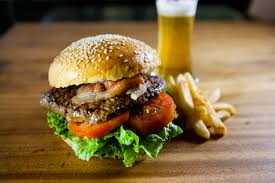

Node: AIMessage
Content: Image loaded: download (6).jpg
--------------------------------------------------
Node: AIMessage
Content: No image found. Please upload your meal image.
--------------------------------------------------
Node: AIMessage
Content: I couldn't find a dish description to analyze. Please describe or upload an image.
--------------------------------------------------
Node: AIMessage
Content: It seems like I missed the description of your meal. Could you please describe what you ate?
--------------------------------------------------


In [47]:
# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="Here's a photo of my meal.")]
    config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

# Claude

In [ ]:
import importlib
importlib.reload(graph_nodes)
from graph_nodes import State, assistant, get_image_path, upload_image, display_image, identify_food, get_calories
from graph_nodes import tools , tools_condition

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Testing graph with image input:
Node: HumanMessage
Content: Here's a photo of my meal.
--------------------------------------------------
Node: AIMessage
Content: 
Tool calls: [{'name': 'get_image_path', 'args': {}, 'id': 'call_7P7LFgAOQPaZ2pj9qRQ9QVTj', 'type': 'tool_call'}]
--------------------------------------------------


Saving Tali.jfif to Tali (5).jfif
✅ Uploaded file: Tali (5).jfif
DEBUG get_image_path returning: {'img_path': Tali (5).jfif}
Node: AIMessage
Content: 
Tool calls: [{'name': 'get_image_path', 'args': {}, 'id': 'call_7P7LFgAOQPaZ2pj9qRQ9QVTj', 'type': 'tool_call'}]
--------------------------------------------------
DEBUG display_image received state keys: ['messages', 'img_path']
Displaying image: Tali (5).jfif


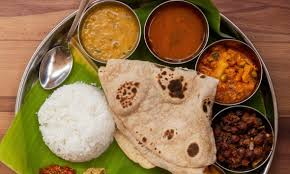

Node: AIMessage
Content: 
Tool calls: [{'name': 'get_image_path', 'args': {}, 'id': 'call_7P7LFgAOQPaZ2pj9qRQ9QVTj', 'type': 'tool_call'}]
--------------------------------------------------
================================== Ai Message ==================================

The dish in the picture you provided appears to be a traditional South Indian thali containing multiple items. Here is a list of typical ingredients for each item along with estimated weights:

1. **Rice** (~150 grams):
   - Rice: 150 grams

2. **Chapati** (2 pieces, ~60 grams each):
   - Whole wheat flour: 50 grams per chapati
   - Water: 10 grams per chapati

3. **Sambar** (~150 grams):
   - Toor dal (split pigeon peas): 50 grams
   - Mixed vegetables (carrot, potato, tomato, etc.): 50 grams
   - Tamarind juice: 20 grams
   - Sambar powder: 5 grams
   - Water: 25 grams

4. **Rasam** (~150 grams):
   - Tomato: 40 grams
   - Tamarind juice: 10 grams
   - Rasam powder: 5 grams
   - Water: 95 grams

5. **Vegetable Curry*

Traceback (most recent call last):
  File "<ipython-input-21-844f7ae4f097>", line 572, in <cell line: 0>
    for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
  File "/usr/local/lib/python3.11/dist-packages/langgraph/pregel/__init__.py", line 2436, in stream
    for _ in runner.tick(
  File "<ipython-input-21-844f7ae4f097>", line 514, in <lambda>
    workflow.add_node("task_mAIstro", lambda state, config: task_mAIstro(state, config, store))
                                                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-21-844f7ae4f097>", line 291, in task_mAIstro
    result = llm.bind_tools(tools, parallel_tool_calls=False).invoke(messages)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/langchain_core/runnables/base.py", line 5430, in invoke
    return self.bound.invoke(
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11

In [ ]:
# Unified graph: supports text or image calorie estimation, then memory updates
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langgraph.graph import MessagesState
from langchain_core.messages import merge_message_runs, HumanMessage, SystemMessage, ToolMessage, AIMessage
from langgraph.prebuilt import ToolNode
from trustcall import create_extractor
from typing import TypedDict, Literal, Union, List, Dict, Any, Optional
from langchain_openai import ChatOpenAI
from datetime import datetime
import uuid
from graph_nodes import State, assistant, get_image_path, upload_image, display_image, identify_food, get_calories
from graph_nodes import tools , tools_condition
from rag import get_rag

# Initialize components
llm = ChatOpenAI(model="gpt-4o")

# Import your existing tools and components
# from graph_nodes import State, assistant, upload_image, display_image, identify_food, get_calories
# from graph_nodes import tools, tools_condition
# from rag import get_rag

# rag_chain = get_rag(llm)

# Memory schemas
class UpdateMemory(TypedDict):
    """Decision on what memory type to update"""
    update_type: Literal['user', 'eating_plan', 'instructions']

from pydantic import BaseModel, Field

class Memory(BaseModel):
    content: str = Field(description="The main content of the memory.")

class Profile(BaseModel):
    """This is the profile of the user you are chatting with"""
    name: Optional[str] = Field(description="The user's name", default=None)
    age: Optional[int] = Field(description="The user's age", default=None)
    weight: Optional[float] = Field(description="The user's weight", default=None)
    height: Optional[float] = Field(description="The user's height", default=None)
    gender: Optional[str] = Field(description="The user's gender", default=None)
    exercise_level: Optional[str] = Field(description="The user's exercise level", default=None)
    diet_type: Optional[str] = Field(description="The user's diet type", default=None)
    allergies: Optional[List[str]] = Field(description="The user's allergies", default_factory=list)
    medications: Optional[List[str]] = Field(description="The user's medications", default_factory=list)
    habits: Optional[List[str]] = Field(description="The user's habits", default_factory=list)
    preferences: Optional[List[str]] = Field(description="The user's preferences", default_factory=list)
    location: Optional[str] = Field(description="The user's location", default=None)
    job: Optional[str] = Field(description="The user's job", default=None)
    diet_goals: List[str] = Field(
        description="The user's dietary goals",
        default_factory=list
    )
    interests: List[str] = Field(
        description="Interests that the user has",
        default_factory=list
    )

class FoodAdviser(BaseModel):
    calorie_estimations: List[str] = Field(
        description="Assistant's calorie estimations for dishes",
        default_factory=list
    )
    food_recommendations: List[str] = Field(
        description="Advice or suggestions regarding food choices",
        default_factory=list
    )
    foods_consumed: List[str] = Field(
        description="Dishes or food items the user reported eating",
        default_factory=list
    )
    current_time: str = Field(
        description="Time of day when the meal was eaten",
        default=""
    )
    timestamp: Optional[str] = Field(
        description="Optional full timestamp for logging",
        default=None
    )

# Tool wrapper for FoodAdviser
class FoodAdviserInputSchema(BaseModel):
    input_data: str
    user_profile: Optional[Dict[str, Any]] = None

class ToolWrapper:
    def __init__(self, func, name: str, description: str, input_schema: BaseModel):
        self.func = func
        self.name = name
        self.description = description
        self.input_schema = input_schema

    def to_openai_function(self) -> Dict:
        return {
            "type": "function",
            "function": {
                "name": self.name,
                "description": self.description,
                "parameters": self.input_schema.model_json_schema()
            }
        }

def food_adviser_function(input_data: str, user_profile: Optional[Dict[str, Any]] = None, config: Optional[RunnableConfig] = None):
    return f"Processed input: {input_data} with profile: {user_profile}"

food_adviser_tool = ToolWrapper(
    func=food_adviser_function,
    name="FoodAdviser",
    description="Provides food recommendations and calorie estimates",
    input_schema=FoodAdviserInputSchema
)

# Instructions
TRUSTCALL_INSTRUCTION = """Reflect on the user's input and determine the appropriate action.

Use these rules:
- If the user shares **personal info** → call UpdateMemory with update_type: 'user'
- If they **describe something they ate** → call UpdateMemory with update_type: 'eating_plan'
- If they give **rules or expectations** → call UpdateMemory with update_type: 'instructions'
- If they **ask for calories or food advice** → call the FoodAdviser tool

Respond naturally after taking any action.
"""

CREATE_INSTRUCTIONS = """Update your instructions for how to handle FoodAdviser items based on user feedback.

Current instructions: {current_instructions}
"""

# Spy class for trustcall
class Spy:
    def __init__(self):
        self.called_tools = []

    def __call__(self, run):
        q = [run]
        while q:
            r = q.pop()
            if r.child_runs:
                q.extend(r.child_runs)
            if r.run_type == "chat_model":
                if hasattr(r, 'outputs') and r.outputs and 'generations' in r.outputs:
                    gen = r.outputs["generations"][0][0]
                    if "message" in gen and "tool_calls" in gen["message"]["kwargs"]:
                        self.called_tools.append(gen["message"]["kwargs"]["tool_calls"])

def extract_tool_info(tool_calls, schema_name="Memory"):
    """Extract information from tool calls"""
    changes = []
    for call_group in tool_calls:
        for call in call_group:
            if call['name'] == 'PatchDoc':
                changes.append({
                    'type': 'update',
                    'doc_id': call['args']['json_doc_id'],
                    'planned_edits': call['args']['planned_edits'],
                    'value': call['args']['patches'][0]['value']
                })
            elif call['name'] == schema_name:
                changes.append({
                    'type': 'new',
                    'value': call['args']
                })

    result_parts = []
    for change in changes:
        if change['type'] == 'update':
            result_parts.append(f"Updated: {change['value']}")
        else:
            result_parts.append(f"New {schema_name}: {change['value']}")

    return "\n".join(result_parts)

# # Node functions
# def assistant(state: MessagesState) -> Dict[str, Any]:
#     """Main assistant node that decides what to do"""
#     # Simple assistant that just responds to basic queries
#     last_message = state["messages"][-1]

#     # Check if this is an image upload request
#     if "photo" in last_message.content.lower() or "image" in last_message.content.lower():
#         # Create a tool call for image upload
#         response = AIMessage(
#             content="I'll help you analyze your meal photo.",
#             tool_calls=[{
#                 "name": "get_image_path",
#                 "args": {},
#                 "id": f"call_{uuid.uuid4().hex[:20]}"
#             }]
#         )
#         return {"messages": [response]}

#     # For other messages, route to task_mAIstro
#     return {"messages": [AIMessage(content="Let me help you with that.")]}

# def get_image_path(state: MessagesState) -> Dict[str, Any]:
#     """Handle image upload - placeholder implementation"""
#     # This should be replaced with your actual image upload logic
#     return {
#         "messages": [ToolMessage(
#             content="Image uploaded successfully. Please provide the actual image for analysis.",
#             tool_call_id=state["messages"][-1].tool_calls[0]["id"]
#         )],
#         "img_path": "/path/to/uploaded/image.jpg"
#     }

# def display_image(state: MessagesState) -> Dict[str, Any]:
#     """Display image - placeholder implementation"""
#     img_path = state.get("img_path", "")
#     return {
#         "messages": [AIMessage(content=f"Displaying image from: {img_path}")],
#         "displayed_image": img_path
#     }

# def identify_food(state: MessagesState) -> Dict[str, Any]:
#     """Identify food from image - placeholder implementation"""
#     return {
#         "messages": [AIMessage(content="I can see a healthy salad with mixed vegetables.")],
#         "img_interpretation": "Mixed green salad with tomatoes, cucumbers, and dressing"
#     }

# def get_calories(state: MessagesState) -> Dict[str, Any]:
#     """Get calorie information"""
#     food_items = state.get("img_interpretation") or "the described food"

#     # Placeholder for RAG chain
#     calorie_info = f"Estimated calories for {food_items}: approximately 150-200 calories"

#     return {
#         "messages": [AIMessage(content=calorie_info)],
#         "calorie_info": calorie_info
#     }

def task_mAIstro(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    """Main reasoning node"""
    user_id = config["configurable"]["user_id"]

    # Get stored information
    profile_item = store.get(("profile", user_id), "user_profile")
    profile = profile_item.value if profile_item else {}

    eating_plan_items = store.search(("eating_plan", user_id))
    eating_plan = "\n".join(str(mem.value) for mem in eating_plan_items)

    instructions_item = store.get(("instructions", user_id), "user_instructions")
    instructions = instructions_item.value.get("memory") if instructions_item else ""

    system_prompt = f"""
{TRUSTCALL_INSTRUCTION}

<user_profile>
{profile}
</user_profile>

<eating_plan>
{eating_plan}
</eating_plan>

<instructions>
{instructions}
</instructions>
"""

    messages = [SystemMessage(content=system_prompt)] + state["messages"]

    # Available tools
    tools = [
        {
            "type": "function",
            "function": {
                "name": "UpdateMemory",
                "description": "Update user memory",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "update_type": {
                            "type": "string",
                            "enum": ["user", "eating_plan", "instructions"]
                        }
                    },
                    "required": ["update_type"]
                }
            }
        },
        food_adviser_tool.to_openai_function()
    ]

    result = llm.bind_tools(tools, parallel_tool_calls=False).invoke(messages)
    return {"messages": [result]}

def update_profile(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    """Update user profile"""
    user_id = config["configurable"]["user_id"]
    namespace = ("profile", user_id)

    # Find the tool call ID to respond to
    tool_call_id = None
    for msg in reversed(state["messages"]):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "user":
                    tool_call_id = tc["id"]
                    break
        if tool_call_id:
            break

    if not tool_call_id:
        return {"messages": [AIMessage(content="⚠️ No tool_call_id found for profile update.")]}

    # Create extractor for profile updates
    existing_items = store.search(namespace)
    existing_memories = [
        (item.key, "Profile", item.value) for item in existing_items
    ] if existing_items else None

    trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
    filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
    updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

    try:
        extractor = create_extractor(llm, tools=[Profile], tool_choice="Profile", enable_inserts=True)
        result = extractor.invoke({"messages": updated_messages, "existing": existing_memories})

        for r, rmeta in zip(result["responses"], result["response_metadata"]):
            store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))

        return {"messages": [ToolMessage(content="User profile updated", tool_call_id=tool_call_id)]}
    except Exception as e:
        return {"messages": [ToolMessage(content=f"Error updating profile: {str(e)}", tool_call_id=tool_call_id)]}

def update_eating_plan(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    """Update eating plan"""
    user_id = config["configurable"]["user_id"]
    namespace = ("eating_plan", user_id)

    # Find the tool call ID
    tool_call_id = None
    for msg in reversed(state["messages"]):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "eating_plan":
                    tool_call_id = tc["id"]
                    break
        if tool_call_id:
            break

    if not tool_call_id:
        return {"messages": [AIMessage(content="⚠️ No tool_call_id found for eating plan update.")]}

    try:
        existing_items = store.search(namespace)
        existing_memories = [
            (item.key, "FoodAdviser", item.value) for item in existing_items
        ] if existing_items else None

        trust_msg = TRUSTCALL_INSTRUCTION.format(time=datetime.now().isoformat())
        filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
        updated_messages = list(merge_message_runs(messages=[SystemMessage(content=trust_msg)] + filtered_messages[:-1]))

        spy = Spy()
        extractor = create_extractor(llm, tools=[FoodAdviser], tool_choice="any", enable_inserts=True).with_listeners(on_end=spy)
        result = extractor.invoke({"messages": updated_messages, "existing": existing_memories})

        for r, rmeta in zip(result["responses"], result["response_metadata"]):
            store.put(namespace, rmeta.get("json_doc_id", str(uuid.uuid4())), r.model_dump(mode="json"))

        update_msg = extract_tool_info(spy.called_tools, "FoodAdviser")
        return {"messages": [ToolMessage(content=update_msg or "Eating plan updated", tool_call_id=tool_call_id)]}
    except Exception as e:
        return {"messages": [ToolMessage(content=f"Error updating eating plan: {str(e)}", tool_call_id=tool_call_id)]}

def update_instructions(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    """Update instructions"""
    user_id = config["configurable"]["user_id"]
    namespace = ("instructions", user_id)
    key = "user_instructions"

    # Find the tool call ID
    tool_call_id = None
    for msg in reversed(state["messages"]):
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                if tc["name"] == "UpdateMemory" and tc["args"].get("update_type") == "instructions":
                    tool_call_id = tc["id"]
                    break
        if tool_call_id:
            break

    if not tool_call_id:
        return {"messages": [AIMessage(content="⚠️ No tool_call_id found for instructions update.")]}

    try:
        existing = store.get(namespace, key)
        current = existing.value.get("memory") if existing and isinstance(existing.value, dict) else ""

        system_msg = CREATE_INSTRUCTIONS.format(current_instructions=current)
        filtered_messages = [msg for msg in state["messages"] if not getattr(msg, "tool_calls", None)]
        result = llm.invoke([SystemMessage(content=system_msg)] + filtered_messages[:-1])

        store.put(namespace, key, {"memory": result.content})
        return {"messages": [ToolMessage(content="Instructions updated", tool_call_id=tool_call_id)]}
    except Exception as e:
        return {"messages": [ToolMessage(content=f"Error updating instructions: {str(e)}", tool_call_id=tool_call_id)]}

def process_food_adviser(state: MessagesState, config: RunnableConfig, store: InMemoryStore):
    """Process food advice requests"""
    message = state['messages'][-1]
    tool_calls = message.tool_calls

    if not tool_calls or tool_calls[0]['name'] != food_adviser_tool.name:
        return {"messages": [AIMessage(content="❌ Expected FoodAdviser tool call not found.")]}

    tool_call = tool_calls[0]
    tool_call_id = tool_call['id']
    tool_args = tool_call['args']

    try:
        input_data = tool_args.get("input_data", "")
        user_profile = tool_args.get("user_profile", {})
        user_id = config["configurable"]["user_id"]

        # Get eating history
        history_items = store.search(("eating_plan", user_id))
        history = "\n".join(str(item.value) for item in history_items[-5:]) if history_items else ""

        # Generate calorie estimate (placeholder)
        calorie_result = f"Estimated calories for '{input_data}': 200-300 calories"

        # Generate advice
        prompt = f"""
You are a nutrition adviser. Provide advice for:

Dish: {input_data}
Calories: {calorie_result}
User Profile: {user_profile}
Recent History: {history}

Give a concise, personalized recommendation.
"""

        result = llm.invoke([HumanMessage(content=prompt)]).content

        # Store the advice
        timestamp = datetime.now().isoformat()
        memory_entry = {
            "content": result,
            "timestamp": timestamp,
            "type": "food_advice",
            "dish": input_data,
            "estimated_calories": calorie_result
        }
        store.put(("eating_plan", user_id), str(uuid.uuid4()), memory_entry)

        combined_content = f"{calorie_result}\n\nAdvice:\n{result}"
        return {"messages": [ToolMessage(content=combined_content, tool_call_id=tool_call_id)]}

    except Exception as e:
        return {"messages": [ToolMessage(content=f"Error: {str(e)}", tool_call_id=tool_call_id)]}

# Routing functions
def route_input_ai(state: MessagesState, config: RunnableConfig, store: InMemoryStore) -> str:
    """Route based on input type"""
    last_message = state["messages"][-1]
    message_text = last_message.content if hasattr(last_message, "content") else ""

    if "photo" in message_text.lower() or "image" in message_text.lower():
        return "get_image_path"
    elif any(word in message_text.lower() for word in ["calories", "food", "eat", "meal", "dish"]):
        return "get_calories"
    else:
        return "task_mAIstro"

def route_message(state: MessagesState, config: RunnableConfig, store: InMemoryStore) -> str:
    """Route based on tool calls"""
    message = state['messages'][-1]

    if not hasattr(message, 'tool_calls') or not message.tool_calls:
        return END

    tool_call = message.tool_calls[0]
    tool_name = tool_call.get("name")
    update_type = tool_call.get("args", {}).get("update_type")

    route_map = {
        ("UpdateMemory", "user"): "update_profile",
        ("UpdateMemory", "eating_plan"): "update_eating_plan",
        ("UpdateMemory", "instructions"): "update_instructions",
        (food_adviser_tool.name, None): "process_food_adviser",
    }

    return route_map.get((tool_name, update_type), END)

def tools_condition(state: MessagesState) -> str:
    """Check if there are tool calls to handle"""
    last_message = state["messages"][-1]
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"
    return END

# Create the graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("assistant", assistant)
workflow.add_node("get_image_path", get_image_path)
workflow.add_node("display_image", display_image)
workflow.add_node("identify_food", identify_food)
workflow.add_node("get_calories", get_calories)

# Add memory nodes with store injection
workflow.add_node("task_mAIstro", lambda state, config: task_mAIstro(state, config, store))
workflow.add_node("update_profile", lambda state, config: update_profile(state, config, store))
workflow.add_node("update_eating_plan", lambda state, config: update_eating_plan(state, config, store))
workflow.add_node("update_instructions", lambda state, config: update_instructions(state, config, store))
workflow.add_node("process_food_adviser", lambda state, config: process_food_adviser(state, config, store))

# Set entry point
workflow.set_entry_point("assistant")

# Add conditional edges
workflow.add_conditional_edges(
    "assistant",
    tools_condition,
    {
        "tools": "get_image_path",
        END: "task_mAIstro"
    }
)

# Image processing flow
workflow.add_edge("get_image_path", "display_image")
workflow.add_edge("display_image", "identify_food")
workflow.add_edge("identify_food", "get_calories")
workflow.add_edge("get_calories", "task_mAIstro")

# Memory routing
workflow.add_conditional_edges(
    "task_mAIstro",
    lambda state, config: route_message(state, config, store),
    {
        "update_profile": "update_profile",
        "update_eating_plan": "update_eating_plan",
        "update_instructions": "update_instructions",
        "process_food_adviser": "process_food_adviser",
        END: END
    }
)

# All memory nodes return to task_mAIstro for final response
workflow.add_edge("update_profile", "task_mAIstro")
workflow.add_edge("update_eating_plan", "task_mAIstro")
workflow.add_edge("update_instructions", "task_mAIstro")
workflow.add_edge("process_food_adviser", "task_mAIstro")

# Compile the graph
checkpointer = MemorySaver()
store = InMemoryStore()
graph = workflow.compile(checkpointer=checkpointer, store=store)

# Test the graph
if __name__ == "__main__":
    from langchain_core.messages import HumanMessage

    input_messages = [HumanMessage(content="Here's a photo of my meal.")]
    config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}

    print("Testing graph with image input:")
    try:
        for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
            last_msg = chunk["messages"][-1]
            print(f"Node: {last_msg.__class__.__name__}")
            print(f"Content: {last_msg.content}")
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                print(f"Tool calls: {last_msg.tool_calls}")
            print("-" * 50)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

In [ ]:
# Tools must be provided in OpenAI function format, not as ToolWrapper objects
# tools = [UpdateMemory, openai_tool]

# Define configuration
config = {"configurable": {"thread_id": "1", "user_id": "Bar"}}
input_messages = [HumanMessage(content="I'm at my favorit resturant. I'm thinking of ordering a pasta with mushrooms and heavy cream. Is it advisable?")]

# # Execute the graph
# for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()

# for chunk in graph.stream({"messages": input_messages, "functions": tools}, config, stream_mode="values"):
#     chunk["messages"][-1].pretty_print()


def continue_after_tool_call(messages, response_message):
    """
    Checks if the response_message contains 'tool_calls'.
    If yes, creates corresponding responses and appends them to the message list.
    """
    # Check if 'tool_calls' are present
    if 'tool_calls' in response_message:
        for tool_call in response_message['tool_calls']:
            # Generate a response message for this tool call
            tool_response_msg = {
                "role": "function",  # or "assistant" depending on your context
                "content": f"Responding to tool call {tool_call['name']}",
                "tool_call_id": tool_call['id']
            }
            # Append the response message
            messages.append(tool_response_msg)
        # After appending responses, you need to re-invoke or continue the conversation
        return messages
    # If no tool_call, just return messages as-is
    return messages

# Usage example with graph.stream()
messages = input_messages.copy()
for chunk in graph.stream({"messages": messages}, config, stream_mode="values"):
    last_msg = chunk["messages"][-1]
    last_msg.pretty_print()

    # Detect if the last message has tool_calls
    if hasattr(last_msg, 'get') and 'tool_calls' in last_msg:
        # Convert message to dict for easier handling
        msg_dict = last_msg.model_dump()
        messages = continue_after_tool_call(messages, msg_dict)
        # Continue the conversation after adding responses
        # Re-invoke or continue as needed
        # For example, re-invoke the graph with updated messages
        result = graph.invoke({"messages": messages}, config=config)
        # Update messages for next iteration
        messages = result["messages"]



================================ Human Message =================================

I'm at my favorit resturant. I'm thinking of ordering a pasta with mushrooms and heavy cream. Is it advisable?


BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_7P7LFgAOQPaZ2pj9qRQ9QVTj", 'type': 'invalid_request_error', 'param': 'messages.[3].role', 'code': None}}